<a href="https://colab.research.google.com/github/Shifash24-hash/AIDS_Sem8_RL_Experiments/blob/main/RL_Exp6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## SHAIKH SHIFA | 221A024 | 53

**Exploration vs. Exploitation Trade-of :
Experimenting with dif erent exploration strategies and
analyzing their impact on the learning performance of an agent in a bandit problem.**

In [ ]:
print("SHAIKH SHIFA | 221A024 | 53 | Exp 6")
import numpy as np
import matplotlib.pyplot as plt

SHAIKH SHIFA | 221A024 | 53 | Exp 6


In [ ]:
print("SHAIKH SHIFA | 221A024 | 53 | Exp 6")
class MultiArmedBandit:
    def __init__(self, k=10):
        self.k = k
        self.q_true = np.random.normal(0, 1, k)
        self.best_arm = np.argmax(self.q_true)

    def pull_arm(self, arm):
      return np.random.normal(self.q_true[arm],1)

SHAIKH SHIFA | 221A024 | 53 | Exp 6


In [ ]:
print("SHAIKH SHIFA | 221A024 | 53 | Exp 6")
class Agent:
    def __init__(self, bandit, strategy="epsilon_greedy", epsilon=0.1, c = 2):
        self.bandit = bandit
        self.strategy = strategy
        self.epsilon = epsilon
        self.c = c
        self.k = bandit.k
        self.Q= np.zeros(self.k) # Estimated rewards
        self.N= np.zeros(self.k) # Number of times each arm was pulled

    def select_action(self, t):
        if self.strategy == "epsilon_greedy":
            if np.random.rand() < self.epsilon:
                return np.random.randint(self.k) # Random action
            else:
                return np.argmax(self.Q)

        elif self.strategy == "ucb1":
            if 0 in self.N:
                return np.argmin(self.N)
            else:
                return np.argmax(self.Q + self.c * np.sqrt(np.log(t + 1) / self.N))

        elif self.strategy == "thompson_sampling":
            samples = np.random.normal(self.Q, 1 / (self.N + 1)) # Sample from belief
            return np.argmax(samples)

    def update(self, arm, reward):
        self.N[arm] += 1
        self.Q[arm] += (reward - self.Q[arm]) / self.N[arm] # Incremental mean

SHAIKH SHIFA | 221A024 | 53 | Exp 6


In [ ]:
print("SHAIKH SHIFA | 221A024 | 53 | Exp 6")
def run_strategy(k=10, steps=1000, runs=200, strategies=["epsilon_greedy", "ucb1"]):
    avg_rewards = {strategy: np.zeros(steps) for strategy in strategies}

    for strategy in strategies:
        for run in range(runs):
            bandit = MultiArmedBandit(k)
            agent = Agent(bandit, strategy=strategy)
            rewards = np.zeros(steps)

            for t in range(steps):
                action = agent.select_action(t)
                reward = bandit.pull_arm(action)
                agent.update(action, reward)
                rewards[t] = reward

            # update average AFTER the run
            avg_rewards[strategy] += rewards / runs

    return avg_rewards

SHAIKH SHIFA | 221A024 | 53 | Exp 6


In [ ]:
print("SHAIKH SHIFA | 221A024 | 53 | Exp 6")
strategies = ["epsilon_greedy", "ucb1"]
results =run_strategy()

SHAIKH SHIFA | 221A024 | 53 | Exp 6


In [ ]:
print("SHAIKH SHIFA | 221A024 | 53 | Exp 6")
results.keys()

SHAIKH SHIFA | 221A024 | 53 | Exp 6


dict_keys(['epsilon_greedy', 'ucb1'])

SHAIKH SHIFA | 221A024 | 53 | Exp 6


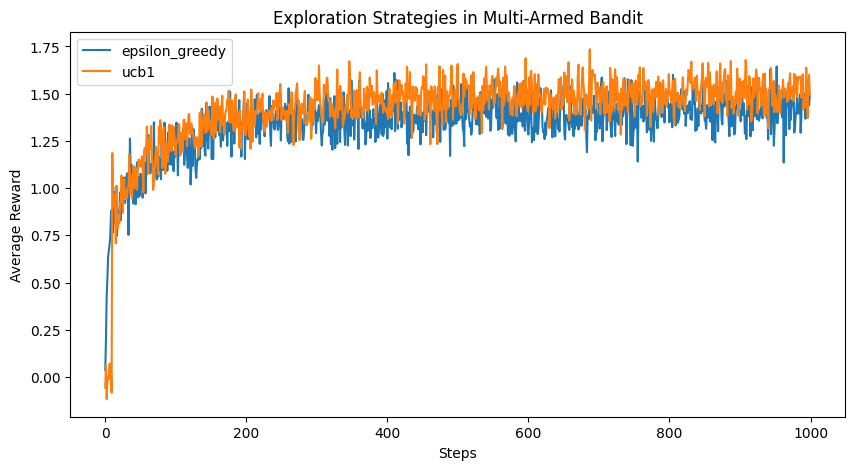

In [ ]:
print("SHAIKH SHIFA | 221A024 | 53 | Exp 6")
# Plot the results
plt.figure(figsize=(10,5))
for strategy, rewards in results.items():
    plt.plot(rewards, label=strategy)
plt.xlabel("Steps")
plt.ylabel("Average Reward")
plt.legend()
plt.title("Exploration Strategies in Multi-Armed Bandit")
plt.show()

Conclusion:- From the graph, we can conclude that UCB1 generally performs better than ε-greedy because it balances exploration and exploitation more effectively. It explores different actions at the beginning and then focuses on the best one, which leads to higher average rewards over time.